# 卷积神经网络可视化

> 没有imagenet_classes.txt

## 1、热力图

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model
from PIL import Image


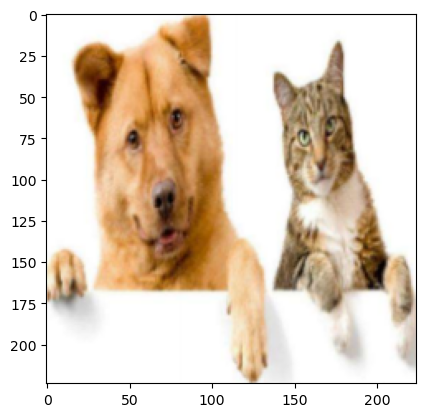

In [8]:
img = cv2.imread('data/dog-and-cat-cover.png')
img = cv2.resize(img, (224,224))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [9]:
# 图像预处理
img_tensor = np.expand_dims(img, axis=0)
preprocessed_img = preprocess_input(img_tensor)

In [10]:
# Import the resnet50 model
model = ResNet50(weights='imagenet')
print(model.summary())

102967424/102967424 [==============================] - 19s 0us/step
Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                       

In [11]:
model.layers[-1].name, model.layers[-4].name

('predictions', 'conv5_block3_add')

In [12]:
# 建立两个模型，分别对应最后一层和最后卷积层的输出
ResNet_model = Model(inputs=model.input,
                     outputs = (model.layers[-4].output, model.layers[-1].output))

In [13]:
# 准备计算梯度，pred_index为预测类型，class_channel为其对应输出
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = ResNet_model(preprocessed_img)
    pred_index = tf.argmax(preds[0])
    class_channel = preds[:, pred_index]

In [14]:
preds.shape, class_channel.shape

(TensorShape([1, 1000]), TensorShape([1]))

In [15]:
# 计算输出对最后卷积层的梯度
grads = tape.gradient(class_channel, last_conv_layer_output)
grads.shape

TensorShape([1, 7, 7, 2048])

In [16]:
# 把梯度在batch维和宽度、高度维度上平均，得到通道加权值
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
pooled_grads.shape

TensorShape([2048])

In [17]:
# [1, 7, 7, 2048]去除batch维度
last_conv_layer_output1 = last_conv_layer_output[0]
# 对最后卷积层进行通道加权后累积计算
heat_map = np.dot(last_conv_layer_output1, pooled_grads)
heat_map.shape

(7, 7)

In [18]:
with open('data/imagenet_classes.txt') as fp:
    classnames = fp.readlines()
predicted_class = classnames[pred_index].strip()
print(predicted_class)

FileNotFoundError: [Errno 2] No such file or directory: 'data/imagenet_classes.txt'

In [19]:
heat_map = cv2.resize(heat_map, (224, 224))

In [ ]:
plt.imshow(img)